# Clase: Descenso de Gradiente, Regresión Lineal y Fundamentos de Redes Neuronales


En esta clase de 2 horas abordaremos los fundamentos teóricos y prácticos del descenso de gradiente, cómo se aplica a la regresión lineal (incluyendo su variante estocástica y con regularización), y finalizaremos con una introducción a las redes neuronales y su entrenamiento.

**Estructura de la clase:**
1. Fundamentos teóricos del Descenso de Gradiente
2. Regresión lineal con descenso de gradiente (Batch, Estocástico y Regularización)
3. Fundamentos de Redes Neuronales


## Parte 1: ¿Qué es el descenso de gradiente?


El descenso de gradiente es un algoritmo de optimización que permite encontrar el mínimo de una función. En Machine Learning, lo usamos para minimizar funciones de costo (loss functions).

### Intuición
Imagina que estás en una montaña y quieres llegar al punto más bajo (mínimo). En cada paso, miras la pendiente y das un paso en dirección opuesta.

### Fórmula general
$$
\theta = \theta - \alpha \cdot \nabla J(\theta)
$$
Donde:
- $\theta$: los parámetros del modelo
- $\alpha$: tasa de aprendizaje
- $\nabla J(\theta)$: gradiente (derivada de la función de costo)


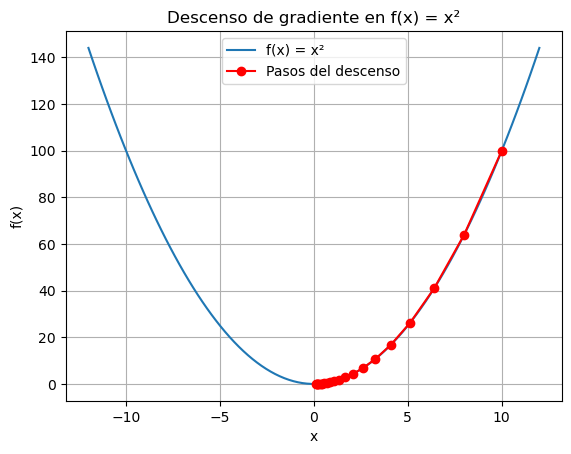

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Función y su derivada
def f(x): return x**2
def df(x): return 2*x

# Inicialización
x = 10
alpha = 0.1
x_hist = [x]

# Iteraciones
for _ in range(20):
    grad = df(x)
    x = x - alpha * grad
    x_hist.append(x)

# Graficar
x_vals = np.linspace(-12, 12, 100)
plt.plot(x_vals, f(x_vals), label='f(x) = x²')
plt.plot(x_hist, f(np.array(x_hist)), 'ro-', label='Pasos del descenso')
plt.title("Descenso de gradiente en f(x) = x²")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()


## Parte 2: Regresión Lineal con Descenso de Gradiente

En esta sección vamos a entrenar un modelo de regresión lineal usando descenso de gradiente. La regresión lineal intenta encontrar la mejor recta que se ajusta a los datos.

**Objetivo:** Encontrar los coeficientes \( \theta \) que minimicen el error cuadrático medio entre las predicciones y los valores reales.

**Cómo funciona:** Usamos descenso de gradiente para actualizar los coeficientes de manera iterativa con base en la derivada (gradiente) de la función de costo. Esto nos permite minimizar el error entre lo predicho y lo observado.

In [2]:
# Datos simulados
np.random.seed(0)
X = 2 * np.random.rand(100, 1)  # Variable independiente
y = 4 + 3 * X + np.random.randn(100, 1)  # Etiquetas con ruido

In [6]:
# Añadir columna de unos para el término de sesgo (intercepto)
X_b = np.c_[np.ones((100, 1)), X]  # X_b.shape = (100, 2)

In [8]:
# Inicialización aleatoria de los parámetros (theta0 y theta1)
theta = np.random.randn(2, 1)
alpha = 0.1  # Tasa de aprendizaje
n_iterations = 1000
m = len(X_b)

# Algoritmo de descenso de gradiente
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)  # Derivada de la función de costo
    theta = theta - alpha * gradients  # Actualización de parámetros

print("Theta final (intercepto y pendiente):", theta.ravel())

Theta final (intercepto y pendiente): [4.22215108 2.96846751]


### Descenso de Gradiente Estocástico (SGD)

El descenso de gradiente estocástico actualiza los parámetros utilizando una sola muestra aleatoria a la vez, lo que lo hace mucho más rápido en datasets grandes.

**Ventajas:**
- Puede escapar de mínimos locales en funciones no convexas
- Permite trabajar con grandes volúmenes de datos sin requerir mucha memoria

**Funcionamiento:** En cada iteración se selecciona un ejemplo aleatorio y se calcula el gradiente para ese único punto.

In [ ]:
# Inicialización aleatoria de parámetros
theta = np.random.randn(2,1)
n_epochs = 50
t0, t1 = 5, 50  # Parámetros para ajustar la tasa de aprendizaje con el tiempo

# Función que define la tasa de aprendizaje decreciente
def learning_rate_schedule(t):
    return t0 / (t + t1)

# Descenso de gradiente estocástico
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        alpha = learning_rate_schedule(epoch * m + i)
        theta = theta - alpha * gradients

print("Theta por SGD:", theta.ravel())

### Regularización con Ridge (L2)

La regularización se usa para prevenir el sobreajuste penalizando los coeficientes grandes. En el caso de Ridge, se suma un término de penalización L2 al costo:

$$ J(\theta) = MSE + \alpha \sum \theta^2 $$

Esto hace que los coeficientes se mantengan más pequeños, lo cual mejora la generalización del modelo.

In [ ]:
from sklearn.linear_model import Ridge

# Entrenamiento del modelo con regularización L2
ridge_reg = Ridge(alpha=1, solver="cholesky")  # alpha controla la fuerza de la regularización
ridge_reg.fit(X, y)
print("Coeficientes con Ridge:", ridge_reg.intercept_, ridge_reg.coef_)

## Parte 3: Fundamentos de Redes Neuronales


Las redes neuronales están inspiradas en el cerebro humano. Están formadas por **neuronas** artificiales organizadas en **capas**.

### Estructura básica:
- Capa de entrada
- Capas ocultas (hidden layers)
- Capa de salida

### Entrenamiento
El entrenamiento usa descenso de gradiente y retropropagación (backpropagation) para ajustar los pesos.

### Ejemplo simple con sklearn


In [9]:

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, alpha=0.01)
mlp.fit(X, y.ravel())
print("Predicción con red neuronal:", mlp.predict([[1.5]]))


Predicción con red neuronal: [8.33289019]


C:\Users\ljpca\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Conclusión


- El descenso de gradiente es la base para entrenar muchos modelos de ML y redes neuronales.
- Aprendimos a implementarlo desde cero y en librerías.
- Las redes neuronales extienden esta idea a modelos más complejos y no lineales.

¡Gracias por asistir a la clase!


## 🧠 Evaluación Final - Takeaways y Reflexión


A continuación, se presentan algunas preguntas teóricas y prácticas para reforzar lo aprendido en esta clase. Responde directamente en el notebook.

### Preguntas de Reflexión
1. ¿Qué representa el gradiente en el contexto del descenso de gradiente?
2. ¿Cuál es la diferencia principal entre el descenso de gradiente batch y el estocástico?
3. ¿Qué impacto tiene la tasa de aprendizaje (learning rate) en la convergencia del modelo?
4. ¿Por qué es útil aplicar regularización en regresión lineal?

### Ejercicio Práctico
Implementa una función `descenso_gradiente_manual(X, y)` que entrene una regresión lineal sin usar librerías externas (como sklearn). Usa descenso de gradiente tradicional (batch) y devuelve los parámetros aprendidos.

```python
def descenso_gradiente_manual(X, y, alpha=0.1, n_iter=500):
    # Agrega columna de 1s
    # Inicializa theta
    # Aplica el algoritmo de descenso de gradiente
    # Devuelve theta
    pass
```

### Pregunta Bonus
5. Explica en tus propias palabras cómo se entrena una red neuronal utilizando el algoritmo de retropropagación y descenso de gradiente.



## ✅ Claves de Respuesta

### Preguntas de Reflexión

1. **¿Qué representa el gradiente en el contexto del descenso de gradiente?**  
   El gradiente representa la dirección y magnitud de la pendiente de la función de costo respecto a los parámetros. Nos indica cómo cambiar los parámetros para reducir el error.

2. **¿Cuál es la diferencia principal entre el descenso de gradiente batch y el estocástico?**  
   - **Batch:** Usa todos los datos para calcular el gradiente en cada iteración.  
   - **Estocástico:** Usa un solo ejemplo aleatorio por iteración, lo que lo hace más ruidoso pero puede converger más rápido.

3. **¿Qué impacto tiene la tasa de aprendizaje (learning rate) en la convergencia del modelo?**  
   Si es muy alta, el modelo puede divergir. Si es muy baja, la convergencia es lenta. Un valor adecuado permite una convergencia eficiente al mínimo.

4. **¿Por qué es útil aplicar regularización en regresión lineal?**  
   Para evitar el sobreajuste penalizando coeficientes grandes. Controla la complejidad del modelo y mejora la generalización.

### Ejercicio Práctico

La implementación esperada debería seguir esta lógica:

```python
def descenso_gradiente_manual(X, y, alpha=0.1, n_iter=500):
    m = len(X)
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.random.randn(2, 1)
    for iteration in range(n_iter):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta -= alpha * gradients
    return theta
```

### Pregunta Bonus

5. **¿Cómo se entrena una red neuronal usando retropropagación y descenso de gradiente?**  
   Se realiza una pasada hacia adelante (forward pass) para calcular la salida y el error. Luego, en la retropropagación se calcula el gradiente del error respecto a cada peso usando la regla de la cadena. Finalmente, se ajustan los pesos utilizando descenso de gradiente para minimizar la función de costo.
